In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay,
    classification_report
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 40

In [3]:
processed_dir = "../data/processed"

X_train = pd.read_csv(f"{processed_dir}/X_train_raw.csv")
X_test = pd.read_csv(f"{processed_dir}/X_test_raw.csv")
y_train = pd.read_csv(f"{processed_dir}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{processed_dir}/y_test.csv").squeeze()


In [4]:
gb = GradientBoostingClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE
)

gb.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",40
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = cross_val_score(gb, X_train, y_train, cv=cv, scoring=metric, n_jobs=-1)
    cv_scores[metric] = scores
    print(f"{metric:10s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

accuracy  : 0.9133 (+/- 0.0033)
precision : 0.8732 (+/- 0.0058)
recall    : 0.8994 (+/- 0.0081)
f1        : 0.8860 (+/- 0.0045)
roc_auc   : 0.9690 (+/- 0.0022)


In [6]:
param_grid = {
    "n_estimators": [150, 300],
    "learning_rate": [0.03, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV roc_auc:", grid_search.best_score_)

gb_best = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 1.0}
Best CV roc_auc: 0.970623872595565


In [7]:
y_pred = gb_best.predict(X_test)
y_proba = gb_best.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}")

accuracy  : 0.9195
precision : 0.8735
recall    : 0.9180
f1        : 0.8952
roc_auc   : 0.9718


In [8]:
print(classification_report(y_test, y_pred, target_names=["FALSE POSITIVE", "CONFIRMED"]))

                precision    recall  f1-score   support

FALSE POSITIVE       0.95      0.92      0.93       917
     CONFIRMED       0.87      0.92      0.90       549

      accuracy                           0.92      1466
     macro avg       0.91      0.92      0.91      1466
  weighted avg       0.92      0.92      0.92      1466



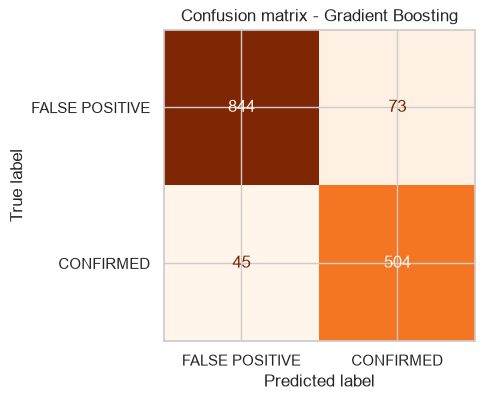

In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FALSE POSITIVE", "CONFIRMED"])
disp.plot(ax=ax, cmap="Oranges", colorbar=False)
plt.title("Confusion matrix - Gradient Boosting")
plt.tight_layout()
plt.show()

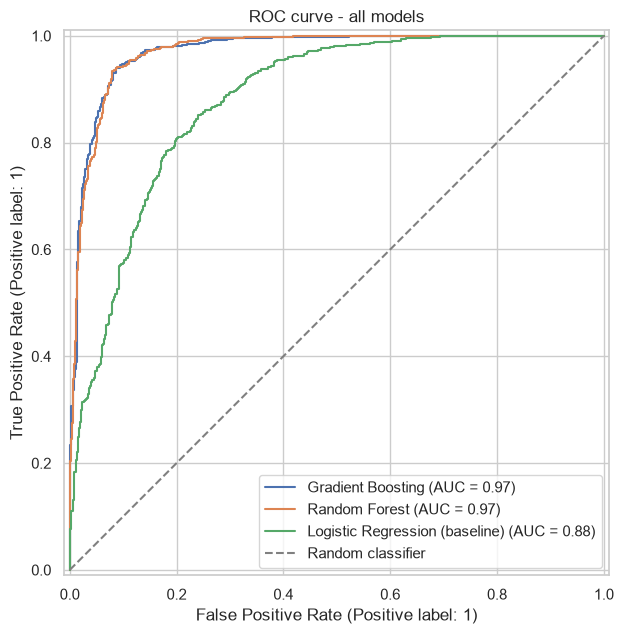

In [10]:
log_reg = joblib.load("../models/baseline_logistic_regression.joblib")
rf_best = joblib.load("../models/random_forest.joblib")

X_test_scaled = pd.read_csv(f"{processed_dir}/X_test.csv")
y_proba_logreg = log_reg.predict_proba(X_test_scaled)[:, 1]
y_proba_rf = rf_best.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name="Gradient Boosting")
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=ax, name="Random Forest")
RocCurveDisplay.from_predictions(y_test, y_proba_logreg, ax=ax, name="Logistic Regression (baseline)")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
ax.set_title("ROC curve - all models")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": gb_best.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
4,koi_prad,0.324168
7,koi_model_snr,0.231743
0,koi_period,0.143251
1,koi_duration,0.100019
5,koi_teq,0.060662
6,koi_insol,0.055656
3,koi_impact,0.052327
2,koi_depth,0.032174


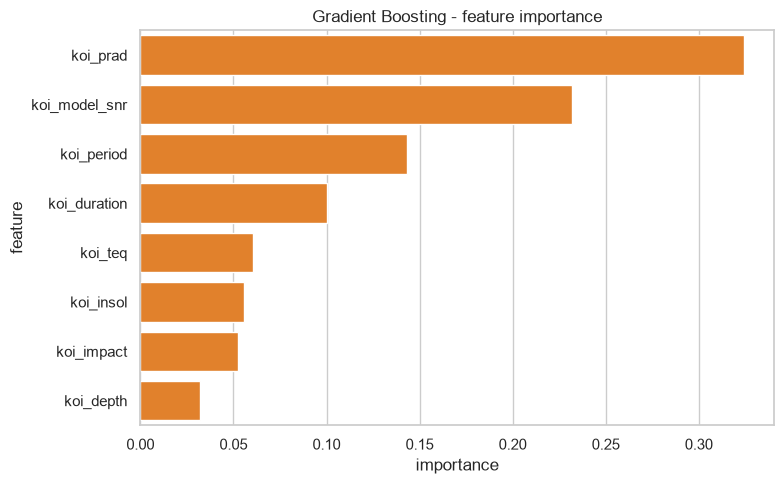

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance", y="feature", color="#ff7f0e")
plt.title("Gradient Boosting - feature importance")
plt.tight_layout()
plt.show()

In [14]:
errors = X_test.copy()
errors["y_true"] = y_test.values
errors["y_pred"] = y_pred
errors["y_proba"] = y_proba
errors["is_error"] = errors["y_true"] != errors["y_pred"]
errors["confidence"] = np.where(errors["y_pred"] == 1, errors["y_proba"], 1 - errors["y_proba"])

print(f"Number of errors: {errors['is_error'].sum()} / {len(errors)} ({errors['is_error'].mean()*100:.2f}%)")

worst_errors = errors[errors["is_error"]].sort_values("confidence", ascending=False)
worst_errors.head(10)

Number of errors: 118 / 1466 (8.05%)


,koi_period,koi_duration,koi_depth,koi_impact,koi_prad,koi_teq,koi_insol,koi_model_snr,y_true,y_pred,y_proba,is_error,confidence
364,9.019471,5.92000,191.6,0.2805,1.07,789.0,91.74,7.2,1,0,0.005066,True,0.994934
356,0.341842,1.15540,285.6,0.9570,1.72,2023.0,3991.16,70.1,1,0,0.013402,True,0.986598
291,13.262554,4.65000,916.4,0.9430,3.55,766.0,81.56,31.4,0,1,0.978406,True,0.978406
721,40.879224,7.00500,413.6,0.7900,1.62,437.0,8.59,23.4,0,1,0.977755,True,0.977755
831,16.178030,5.18000,449.0,0.0810,2.25,754.0,76.54,6.0,1,0,0.023123,True,0.976877
846,14.170987,3.48040,3070.8,0.0410,4.19,608.0,32.22,93.6,0,1,0.975456,True,0.975456
1377,27.807566,4.21587,25391.1,0.7820,13.84,554.0,22.24,748.1,1,0,0.025993,True,0.974007
918,88.180468,5.03300,1138.6,0.0260,2.78,359.0,3.94,17.5,0,1,0.973420,True,0.973420
231,4.309086,1.52000,160.8,0.8710,1.62,1172.0,445.13,17.0,0,1,0.973371,True,0.973371
856,10.161048,3.04480,908.9,0.0310,2.72,800.0,96.98,36.8,0,1,0.972672,True,0.972672


In [15]:
models_dir = Path("../models")
joblib.dump(gb_best, models_dir / "gradient_boosting.joblib")

results_summary = pd.read_csv(models_dir / "baseline_results.csv")

new_row = pd.DataFrame([{
    "model": "GradientBoosting (tuned)",
    **metrics
}])

results_summary = pd.concat([results_summary, new_row], ignore_index=True)
results_summary.to_csv(models_dir / "baseline_results.csv", index=False)

print("Updated results table:")
results_summary

Updated results table:


,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression (baseline),0.775580,0.645503,0.888889,0.747893,0.879960
1,RandomForest (tuned),0.916780,0.850575,0.943534,0.894646,0.971234
2,GradientBoosting (tuned),0.919509,0.873484,0.918033,0.895204,0.971849
